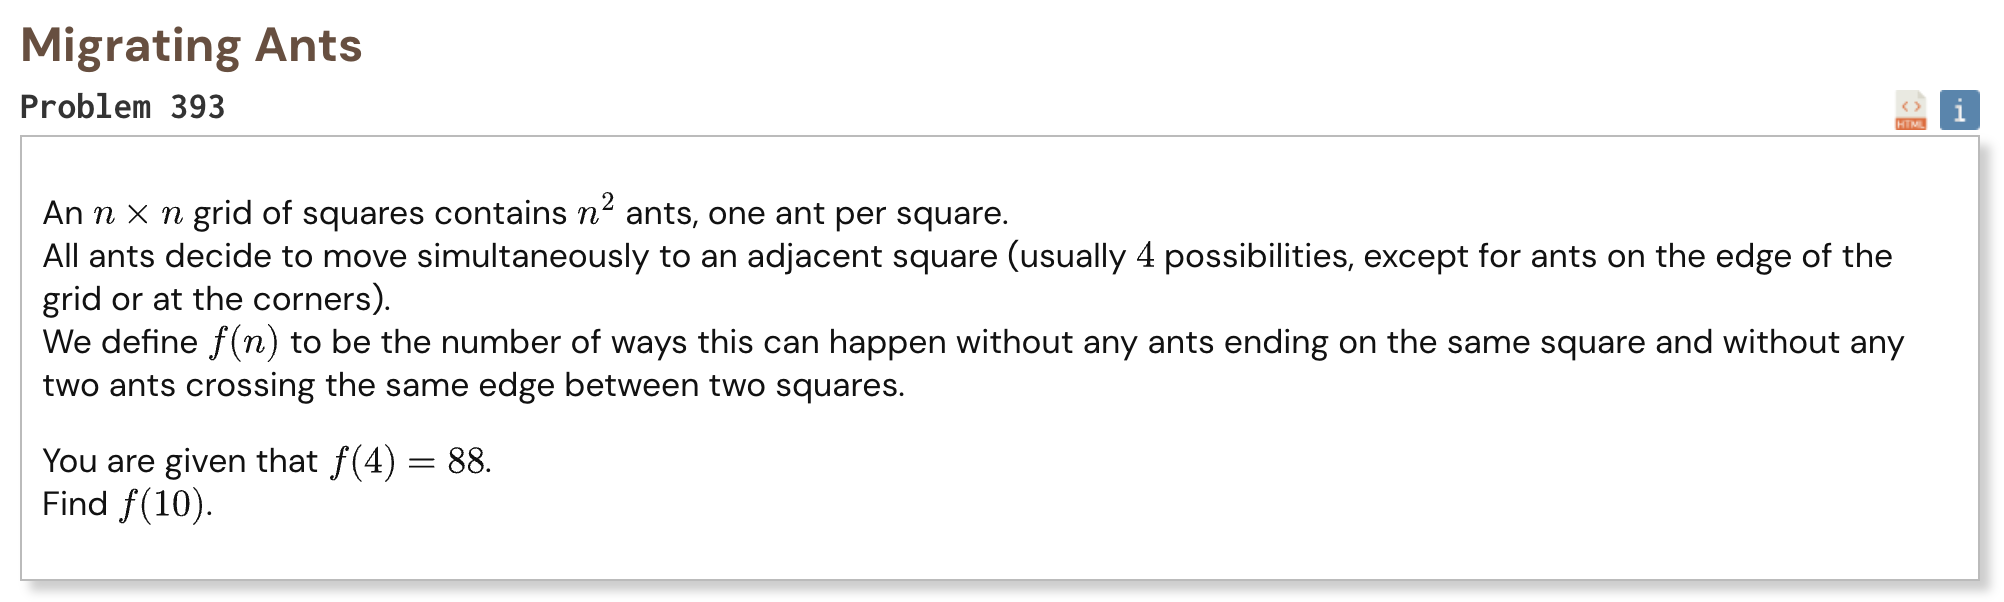

## Initial approach

-   color the grid like a chessboard because every move goes between opposite colors
-   the moves from black squares form one perfect matching
-   the moves from white squares form another perfect matching
-   the two matchings cannot use the same edge because that would make two ants swap places
-   process the grid one row at a time and remember vertical edges coming from the previous row
-   for each cell choose whether each matching continues right or down
-   reject choices that leave a cell unmatched or use the same edge in both matchings
-   after the final row only the state with no unfinished vertical edges is valid

In [1]:
from collections import defaultdict
from functools import lru_cache


def solve(n):
    @lru_cache(None)
    def transitions(up_black, up_white, last_row):
        results = defaultdict(int)

        def search(column, left_black, left_white, down_black, down_white):
            if column == n:
                if not left_black and not left_white:
                    results[(down_black, down_white)] += 1
                return

            top_black = (up_black >> column) & 1
            top_white = (up_white >> column) & 1

            if top_black and left_black:
                return

            if top_white and left_white:
                return

            black_matched = top_black or left_black
            white_matched = top_white or left_white

            if black_matched:
                black_options = [0]
            else:
                black_options = []

                if column + 1 < n:
                    black_options.append(1)

                if not last_row:
                    black_options.append(2)

            if white_matched:
                white_options = [0]
            else:
                white_options = []

                if column + 1 < n:
                    white_options.append(1)

                if not last_row:
                    white_options.append(2)

            for black_choice in black_options:
                for white_choice in white_options:
                    if black_choice == white_choice and black_choice != 0:
                        continue

                    next_down_black = down_black
                    next_down_white = down_white

                    if black_choice == 2:
                        next_down_black |= 1 << column

                    if white_choice == 2:
                        next_down_white |= 1 << column

                    search(
                        column + 1,
                        black_choice == 1,
                        white_choice == 1,
                        next_down_black,
                        next_down_white
                    )

        search(0, False, False, 0, 0)

        return tuple(results.items())

    states = {(0, 0): 1}

    for row in range(n):
        next_states = defaultdict(int)
        last_row = row == n - 1

        for (up_black, up_white), count in states.items():
            for next_state, ways in transitions(
                up_black,
                up_white,
                last_row
            ):
                next_states[next_state] += count * ways

        states = next_states

    return states.get((0, 0), 0)

In [2]:
%%time
assert solve(4) == 88
result = solve(10)
print("Result:", result)

Result: 112398351350823112
CPU times: user 776 ms, sys: 28 ms, total: 804 ms
Wall time: 823 ms
